MODELE DE RESEAU DE NEURONES CONVOLUTIFS

In [1]:
'''
Modèle CNN avec Transfer Learning ResNet50


'''

'\nModèle CNN avec Transfer Learning ResNet50\n\n\n'

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 137.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 7.1 MB/s eta 0:00:00


In [3]:
# Import des librairies principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Importation pour la transformation des images
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomContrast


# Imports nécessaires pour construire / sauvegarder / évaluer le modèle
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
#rom tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras import regularizers

from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
# Définition des chemins d'accès

rep_img = '/content/gdrive/My Drive/Colab Notebooks/Champi gras Cake/DataScience_images_Especes3'
rep_model = "/content/gdrive/My Drive/Colab Notebooks/Champi gras Cake/models3/"

In [6]:
# Importation de l'utilitaire image_dataset_from_directory de Keras

train_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,     # 30% réservé pour val + test
    subset="training",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)

# Dataset temporaire qui va être divisé en 15% validation et 15% test
temp_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,
    subset="validation",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)

Found 25913 files belonging to 30 classes.
Using 18140 files for training.
Found 25913 files belonging to 30 classes.
Using 7773 files for validation.


In [7]:
# Découpage du dataset temp en validation + test


temp_size = tf.data.experimental.cardinality(temp_ds).numpy()

val_size = temp_size // 2
test_size = temp_size - val_size

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [8]:
# Optimisation du pipeline

AUTOTUNE = tf.data.AUTOTUNE   # Optimisation automatique du nombre de fichiers et threads à charger

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE) # Pour garder en mémoire les images et gagner en vitesse // shuffle pour mélanger les images à chaque epoch pour un meilleur apprentissage
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)




In [9]:
# Nombre de lot dans l'ensemble d'entraînement
print("Nombre de batch dans train_ds:", train_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de validation
print("Nombre de batch dans val_ds:", val_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de test
print("Nombre de batch dans test_ds:", test_ds.cardinality().numpy())

Nombre de batch dans train_ds: 284
Nombre de batch dans val_ds: 61
Nombre de batch dans test_ds: 61


In [10]:
# Définir des couches de transformation
random_translation = RandomTranslation(0.1, 0.1)   # Étirement
random_zoom = RandomZoom(0.1)                      # Agrandissement
random_flip = RandomFlip("horizontal")             # Retournement horizontal
random_rotation = RandomRotation(0.1)              # Rotation
random_contrast = RandomContrast(0.1)              # Contraste

In [11]:
# Récupération de 16 images et affichage

for batch_images, batch_labels in train_ds.take(1):
    images = batch_images[:16]
    labels = batch_labels[:16]

plt.figure(figsize=(12, 32))

for i in range(16):
    image = images[i]  # Récupérer la ième image

    # Appliquer les transformations
    x = random_translation(image)   # Etirement
    x = random_zoom(x)              # Zoom
    x = random_flip(x)              # Retournement
    x = random_rotation(x)          # Rotation
    x = random_contrast(x)          # Contraste

    # Afficher l'image originale
    plt.subplot(16, 2, 2*i + 1)  # Position dans la grille
    plt.imshow(image.numpy().astype("uint8"))
    plt.axis("off")

    # Afficher l'image transformée
    plt.subplot(16, 2, 2*i + 2)  # Position dans la grille
    plt.imshow(x.numpy().astype("uint8"))
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [12]:

NUM_CLASSES = 30

inputs = Input(shape=(224, 224, 3))

# Data augmentation
x = random_translation(inputs)
x = random_zoom(x)
x = random_flip(x)
x = random_rotation(x)
x = random_contrast(x)

# Préprocess ResNet50 (à la place du Rescaling)
x = preprocess_input(x)

# Backbone ResNet50
base_model = ResNet50(
    include_top=False,          # on enlève la couche de classification ImageNet
    weights="imagenet",
    input_tensor=x
)

base_model.trainable = False    # phase 1 : on gèle

# Tête de classification
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model_resnet = Model(inputs, outputs)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [13]:
# Callback pour sauvegarder le modèle
'''save = ModelCheckpoint(
                        rep_model+'CNN_TL_model.h5',
                        save_best_only=True,
                        monitor='val_loss',
                        mode='min'
                    )'''


save = tf.keras.callbacks.ModelCheckpoint(
    rep_model + "CNN_TL_model.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True
)



# Callback pour réduire le taux d'apprentissage
reduceLR = ReduceLROnPlateau(
                                monitor="val_loss",
                                mode="min",
                                patience=3,
                                factor=0.5,
                                min_delta=0.001,
                                cooldown=1,
                                min_lr=1e-6,
                                verbose=1
                                    )

# Callback pour stopper l'apprentissage quand il ne progresse plus
early_stop = EarlyStopping(
                                patience=6,     # Nombre d'époques sans amélioration avant arrêt
                                min_delta=0.001,
                                mode='min',
                                monitor='val_loss',    # On surveille la perte sur l'ensemble de validation
                                restore_best_weights=True)

In [14]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [15]:
history_model1 = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,                  # 15 voire 20
    callbacks=[reduceLR, save, early_stop]
)

Epoch 1/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.3789 - loss: 2.2694 - val_accuracy: 0.6616 - val_loss: 1.0843 - learning_rate: 0.0010
Epoch 2/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 146s 513ms/step - accuracy: 0.6476 - loss: 1.1615 - val_accuracy: 0.7418 - val_loss: 0.8515 - learning_rate: 0.0010
Epoch 3/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 145s 513ms/step - accuracy: 0.7095 - loss: 0.9488 - val_accuracy: 0.7723 - val_loss: 0.7627 - learning_rate: 0.0010
Epoch 4/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 145s 512ms/step - accuracy: 0.7601 - loss: 0.7825 - val_accuracy: 0.7679 - val_loss: 0.7401 - learning_rate: 0.0010
Epoch 5/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 145s 510ms/step - accuracy: 0.7728 - loss: 0.7224 - val_accuracy: 0.7713 - val_loss: 0.7707 - learning_rate: 0.0010
Epoch 6/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 146s 514ms/step - accuracy: 0.8006 - loss: 0.6374 - val_accuracy: 0.7836 - val_loss: 0.7137 - learning_rate: 0.0010
Epoch 7/20
284/284 ━━━━━━━━━━━━━━━━━━━━ 145s 512ms/step - accuracy:

In [16]:
# Dégèle
base_model.trainable = True

fine_tune_at = 140  # ResNet50 a environ 175 couches
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False




In [17]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [18]:
history_model2 = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[reduceLR, save, early_stop]
)

Epoch 1/40
284/284 ━━━━━━━━━━━━━━━━━━━━ 205s 698ms/step - accuracy: 0.7747 - loss: 0.7618 - val_accuracy: 0.8591 - val_loss: 0.5077 - learning_rate: 1.0000e-05
Epoch 2/40
284/284 ━━━━━━━━━━━━━━━━━━━━ 198s 696ms/step - accuracy: 0.8923 - loss: 0.3256 - val_accuracy: 0.8665 - val_loss: 0.4875 - learning_rate: 1.0000e-05
Epoch 3/40
284/284 ━━━━━━━━━━━━━━━━━━━━ 197s 694ms/step - accuracy: 0.9199 - loss: 0.2477 - val_accuracy: 0.8694 - val_loss: 0.4903 - learning_rate: 1.0000e-05
Epoch 4/40
284/284 ━━━━━━━━━━━━━━━━━━━━ 197s 696ms/step - accuracy: 0.9334 - loss: 0.2022 - val_accuracy: 0.8781 - val_loss: 0.4555 - learning_rate: 1.0000e-05
Epoch 5/40
284/284 ━━━━━━━━━━━━━━━━━━━━ 198s 697ms/step - accuracy: 0.9384 - loss: 0.1853 - val_accuracy: 0.8835 - val_loss: 0.4515 - learning_rate: 1.0000e-05
Epoch 6/40
284/284 ━━━━━━━━━━━━━━━━━━━━ 198s 698ms/step - accuracy: 0.9537 - loss: 0.1492 - val_accuracy: 0.8873 - val_loss: 0.4467 - learning_rate: 1.0000e-05
Epoch 7/40
284/284 ━━━━━━━━━━━━━━━━━━━━ 

In [19]:
np.save(rep_model+"CNN_TL_model_history.npy", history_model2.history)

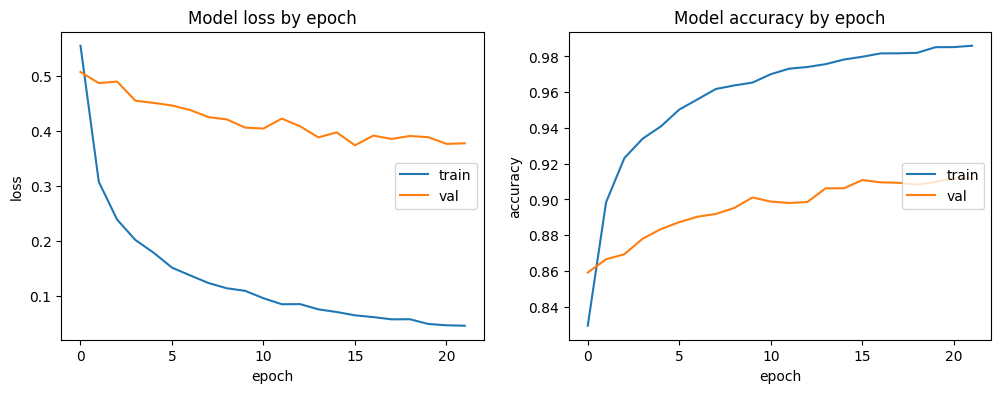

In [20]:
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(history_model2.history['loss'])
plt.plot(history_model2.history['val_loss'])
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')

plt.subplot(122)
plt.plot(history_model2.history['accuracy'])
plt.plot(history_model2.history['val_accuracy'])
plt.title('Model accuracy by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')
plt.show()

In [21]:
# Fonction pour obtenir les prédictions

def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model_resnet.predict(images, verbose=0)
        pred_labels.extend(np.argmax(preds, axis=-1))

        true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)     # test, pas val

# Afficher le rapport de classification
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       123
           1       0.85      0.83      0.84       115
           2       0.86      0.88      0.87       148
           3       0.73      0.87      0.79       122
           4       0.84      0.73      0.78       109
           5       0.90      0.74      0.82       145
           6       0.98      0.99      0.99       124
           7       0.72      0.93      0.82       135
           8       0.97      0.94      0.95       122
           9       0.94      0.82      0.88       125
          10       0.83      0.91      0.87       128
          11       0.97      0.94      0.95       129
          12       0.97      0.93      0.95       125
          13       0.79      0.97      0.87       139
          14       0.93      0.79      0.85       126
          15       0.96      0.84      0.90       128
          16       0.93      0.95      0.94       133
          17       0.96    

<Axes: >

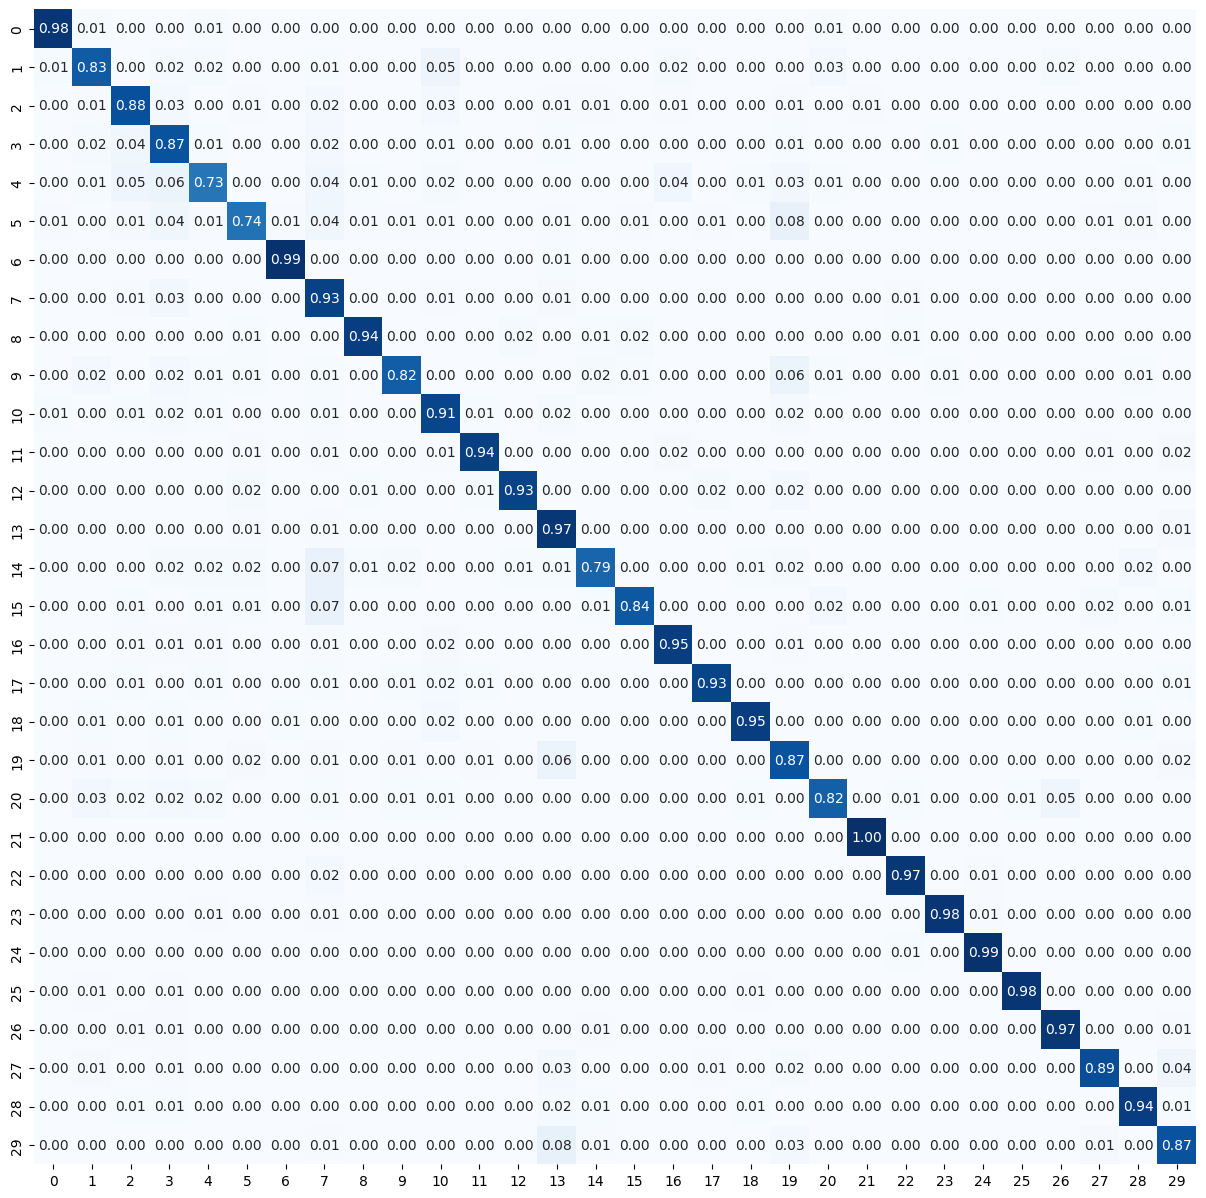

In [22]:
# Affichage de la matrice de confusion

plt.figure(figsize=(15, 15))
cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")